### Setup Data Train-Test 
    Before modeling step, first step is setup data for training and testing

Data traning will take 80% of all data

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# library
import glob
import random

# Read data from normal & SCD in directory
normalList = glob.glob("/content/drive/My Drive/Thesis/Grayscale/Normal/*")
scdList = glob.glob("/content/drive/My Drive/Thesis/Grayscale/SCD/*")

# setup train of size
trainSize = 0.8 # 80% of data will use for training

# calculate train size normal and SCD data
scdSize = int(len(scdList)*0.8)
normalSize = int(len(normalList)*0.8)

# generate random data for train and test in SCD
scdTrain = random.sample(scdList, k=round(scdSize))
scdTest = list(set(scdList) - set(scdTrain))

# generate random data for train and test in normal
normalTrain = random.sample(normalList, k=round(normalSize))
normalTest = list(set(normalList) - set(normalTrain))

# Show data for training
print('--- Training Dataset ----')
print(scdTrain)
print(normalTrain)

print()

# Show data for testing
print('--- Testing Dataset ----')
print(scdTest)
print(normalTest)

--- Training Dataset ----
['/content/drive/My Drive/Thesis/Grayscale/SCD/scd - 33.png', '/content/drive/My Drive/Thesis/Grayscale/SCD/scd - 46.png', '/content/drive/My Drive/Thesis/Grayscale/SCD/scd - 48.png', '/content/drive/My Drive/Thesis/Grayscale/SCD/scd - 47.png', '/content/drive/My Drive/Thesis/Grayscale/SCD/scd - 35.png', '/content/drive/My Drive/Thesis/Grayscale/SCD/scd - 37.png', '/content/drive/My Drive/Thesis/Grayscale/SCD/scd - 32.png', '/content/drive/My Drive/Thesis/Grayscale/SCD/scd - 45.png', '/content/drive/My Drive/Thesis/Grayscale/SCD/scd - 43.png', '/content/drive/My Drive/Thesis/Grayscale/SCD/scd - 50.png', '/content/drive/My Drive/Thesis/Grayscale/SCD/scd - 31.png', '/content/drive/My Drive/Thesis/Grayscale/SCD/scd - 41.png', '/content/drive/My Drive/Thesis/Grayscale/SCD/scd - 44.png', '/content/drive/My Drive/Thesis/Grayscale/SCD/scd - 30.png', '/content/drive/My Drive/Thesis/Grayscale/SCD/scd - 39.png', '/content/drive/My Drive/Thesis/Grayscale/SCD/scd - 49.png

In [3]:
# # library
# import shutil

# # function for change directory of dst
# def changeDirectory(data, directory, new):
#     start = len(directory)
#     values = []
#     for i in range(0,len(data)):
#         values.append(new+data[i][start:len(data[i])])
#     return(values)


# # get new directory 
# scdTrainDst = changeDirectory(scdTrain, '/content/drive/My Drive/Thesis/Grayscale/SCD/', '/content/drive/My Drive/Thesis/Train-Min/SCD/')
# scdTestDst = changeDirectory(scdTest, '/content/drive/My Drive/Thesis/Grayscale/SCD/', '/content/drive/My Drive/Thesis/Test-Min/SCD/')
# normalTrainDst = changeDirectory(normalTrain, '/content/drive/My Drive/Thesis/Grayscale/Normal/', '/content/drive/My Drive/Thesis/Train-Min/Normal/')
# normalTestDst = changeDirectory(normalTest, '/content/drive/My Drive/Thesis/Grayscale/Normal/', '/content/drive/My Drive/Thesis/Test-Min/Normal/')

# # copy the data
# def copyData(dtSrc, dtDst):
#     for i in range(1, len(dtSrc)):
#         shutil.copyfile(dtSrc[i], dtDst[i])

# copyData(scdTrain, scdTrainDst)
# copyData(scdTest, scdTestDst)
# copyData(normalTrain, normalTrainDst)
# copyData(normalTest, normalTestDst)

In [4]:
# Show current data in Train and Test

print('--- Training Dataset ---')
listTrain = glob.glob("/content/drive/My Drive/Thesis/Train-Min/SCD/*")
for v in listTrain:
    print(v)
listTrain = glob.glob("/content/drive/My Drive/Thesis/Train-Min/Normal/*")
for v in listTrain:
    print(v)

print()

print('--- Testing Dataset ---')
listTest = glob.glob("/content/drive/My Drive/Thesis/Test-Min/SCD/*")
for v in listTest:
    print(v)
listTest = glob.glob("/content/drive/My Drive/Thesis/Test-Min/Normal/*")
for v in listTest:
    print(v)

--- Training Dataset ---
/content/drive/My Drive/Thesis/Train-Min/SCD/scd - 32.png
/content/drive/My Drive/Thesis/Train-Min/SCD/scd - 30.png
/content/drive/My Drive/Thesis/Train-Min/SCD/scd - 31.png
/content/drive/My Drive/Thesis/Train-Min/Normal/normal - 16272.png
/content/drive/My Drive/Thesis/Train-Min/Normal/normal - 16420.png
/content/drive/My Drive/Thesis/Train-Min/Normal/normal - 16483.png

--- Testing Dataset ---
/content/drive/My Drive/Thesis/Test-Min/SCD/scd - 37.png
/content/drive/My Drive/Thesis/Test-Min/Normal/normal - 16265.png


### We have done to roadmap the train and testing data. It makes more easier for buidling Classication Model

## Modeling step

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

import keras
from keras.models import Sequential
from keras.layers import Dense, Conv2D , MaxPooling2D , Flatten , Dropout, LSTM, Bidirectional, Lambda, Reshape, GlobalMaxPooling2D
from tensorflow.keras import layers
from keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import classification_report,confusion_matrix, f1_score

import tensorflow as tf

from skimage import io
import cv2
import os

import numpy as np
import pandas as pd

### Read Dataset

In [6]:
labels = ['Normal', 'SCD']
img_size = 244 

def get_data(data_dir):
    data = [] 
    for label in labels: 
        path = os.path.join(data_dir, label)
        class_num = labels.index(label)
        for img in os.listdir(path):
            try:
                img_arr = cv2.imread(os.path.join(path, img))[...,::-1] #convert BGR to RGB format
                resized_arr = cv2.resize(img_arr, (3000, 400)) # Reshaping images to preferred size
                data.append([resized_arr, class_num])
            except Exception as e:
                print(e)
    return np.array(data)

In [7]:
# Read the data train and test
train = get_data('/content/drive/My Drive/Thesis/Train-Min')
test = get_data('/content/drive/My Drive/Thesis/Test-Min')

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:16: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  app.launch_new_instance()


/usr/local/lib/python3.7/dist-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


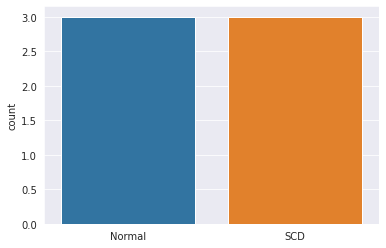

In [8]:
# Visualize train data
l = []
for i in train:
    if(i[1] == 0):
        l.append("Normal")
    else:
        l.append("SCD")
sns.set_style('darkgrid')
sns.countplot(l)

/usr/local/lib/python3.7/dist-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


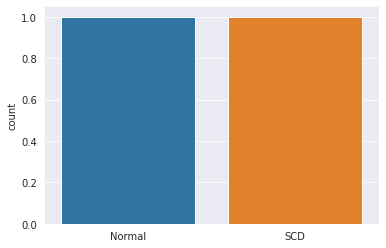

In [9]:
# Visualize test data
l = []
for i in test:
    if(i[1] == 0):
        l.append("Normal")
    else:
        l.append("SCD")
sns.set_style('darkgrid')
sns.countplot(l)

Text(0.5, 1.0, 'Normal')



In [10]:
# check the image data
plt.figure(figsize = (img_size,img_size))
plt.imshow(train[0][0])
plt.title(labels[train[0][1]])

In [11]:
# check size of data
test[0][0].shape[1::-1]

(3000, 400)

## Pre-pare Dataset

In [12]:
# Pre pare the dataset
x_train = []
y_train = []
x_test = []
y_test = []

# Label 0 is normal
# Label 1 is SCD
for feature, label in train:
    x_train.append(feature)
    y_train.append(label)

for feature, label in test:
    x_test.append(feature)
    y_test.append(label)

print(x_train)
print(y_train)

[array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]

In [13]:
# Normalize the data
x_train = np.array(x_train) / 255
x_test = np.array(x_test) / 255

In [14]:
# change the target into numpy values
y_train = np.array(y_train)
y_test = np.array(y_test)

In [15]:
# Check shape of data training
x_train.shape 

(6, 400, 3000, 3)

## Create CNN LSTM Image Classification Model

#### Function or Method use for modeling process

In [16]:
# Function for reshape matrix value
# It's used for handle value output from CNN into LSTM model

def ReshapeLayer(x):
    shape = x.shape
    
    # 1 possibility: H,W*channel
    reshape = layers.Reshape((shape[1],shape[2]*shape[3]))(x)
    
    # 2 possibility: W,H*channel
    # transpose = Permute((2,1,3))(x)
    # reshape = Reshape((shape[1],shape[2]*shape[3]))(transpose)
    return reshape

# Show report precision and prediction
def evalution(y_test, prediction_class):
    tn, fp, fn, tp = confusion_matrix(y_test, prediction_class).ravel()

    accuracy = round((tp+tn)/(tp+tn+fn+fp), 3)
    sensitivity = round(tp/(tp+fn), 3)
    specificity = round(tn/(tn+fp), 3)
    precision = round(tp/(fp+tp), 3)
    f1 = round(f1_score(y_test, prediction_class), 3)

    print('Evaluation Result')
    print('-----------------')
    print('Accuracy:    ', accuracy)
    print('Sensitivity: ', sensitivity)
    print('Specificity: ', specificity)
    print('Precision:   ', precision)
    print('F1 Score:    ', f1)
    
    print('\n\n')
    
    array = confusion_matrix(y_test, prediction_class)

    df_cm = pd.DataFrame(array, columns=['Normal', 'SCD'])
    df_cm.index = ['Normal', 'SCD']

    plt.figure(figsize=(10,7))
    plt.title('Plotting Confusion Matrix Result')
    sns.set(font_scale=1.4) # for label size
    sns.heatmap(df_cm, annot=True, annot_kws={"size": 16}, cmap="YlGnBu") # font size

    plt.show()

In [17]:
# Data augmentation
# Input data training into keras preprocessing for image classification
datagen = ImageDataGenerator(
        featurewise_center=False,  # set input mean to 0 over the dataset
        samplewise_center=False,  # set each sample mean to 0
        featurewise_std_normalization=False,  # divide inputs by std of the dataset
        samplewise_std_normalization=False,  # divide each input by its std
        zca_whitening=False,  # apply ZCA whitening
        rotation_range = 30,  # randomly rotate images in the range (degrees, 0 to 180)
        zoom_range = 0.2, # Randomly zoom image 
        width_shift_range=0.1,  # randomly shift images horizontally (fraction of total width)
        height_shift_range=0.1,  # randomly shift images vertically (fraction of total height)
        horizontal_flip = True,  # randomly flip images
        vertical_flip=False)  # randomly flip images

datagen.fit(x_train)

In [18]:
tf.keras.backend.clear_session()
with tf.device('/device:GPU:0'):
    # Define model using keras
    model = Sequential()

    # add layer 1, 2, & 3: Conv2D, Conv2D, MaxPool
    model.add(Conv2D(64, (3, 3), strides=1, activation='relu', input_shape=(400, 3000, 3)))
    model.add(Conv2D(64, (3, 3), strides=1, activation='relu'))
    model.add(MaxPooling2D((2, 2), strides=2))

    # add layer 4, 5, & 6: Conv2D, Conv2D, MaxPool
    model.add(Conv2D(128, (3, 3), strides=1, activation='relu'))
    model.add(Conv2D(128, (3, 3), strides=1, activation='relu'))
    model.add(MaxPooling2D((2, 2), strides=2))

    # add layer 7, 8, & 9: Conv2D, Conv2D, MaxPool
    model.add(Conv2D(256, (3, 3), strides=1, activation='relu'))
    model.add(Conv2D(256, (3, 3), strides=1, activation='relu'))
    model.add(MaxPooling2D((2, 2), strides=2))

    # add layer 10: LSTM
    model.add(Lambda(ReshapeLayer)) # <========== pass from 4D to 3D
    model.add(Bidirectional(LSTM(256, activation='relu', return_sequences=False)))
    #flatten since too many dimensions, we only want a classification output
    model.add(Flatten())
    # add layer 11 & 12: fully connected
    model.add(Dense(128,activation="relu"))
    model.add(Dense(8,activation="relu"))
    model.add(Dropout(0.5))
#     model.add(Dense(8,activation="relu"))

    # last is predicted result
    model.add(Dense(2, activation="softmax"))

    model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 398, 2998, 64)     1792      
                                                                 
 conv2d_1 (Conv2D)           (None, 396, 2996, 64)     36928     
                                                                 
 max_pooling2d (MaxPooling2D  (None, 198, 1498, 64)    0         
 )                                                               
                                                                 
 conv2d_2 (Conv2D)           (None, 196, 1496, 128)    73856     
                                                                 
 conv2d_3 (Conv2D)           (None, 194, 1494, 128)    147584    
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 97, 747, 128)     0         
 2D)                                                    

### Training the data

In [19]:
    # Start training
    opt = Adam(learning_rate=0.0001)
    model.compile(optimizer = opt , loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True) , metrics = ['accuracy'])

    # Training Model process and save the result into history 
    history = model.fit(x_train,y_train, epochs = 100, validation_data = (x_test, y_test))

Epoch 1/100


/usr/local/lib/python3.7/dist-packages/tensorflow/python/util/dispatch.py:1082: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a sigmoid or softmax activation and thus does not represent logits. Was this intended?"
  return dispatch_target(*args, **kwargs)


1/1 [==============================] - 21s 21s/step - loss: 0.6789 - accuracy: 0.8333 - val_loss: 0.7070 - val_accuracy: 0.5000
Epoch 2/100
1/1 [==============================] - 2s 2s/step - loss: 0.7533 - accuracy: 0.6667 - val_loss: 0.6982 - val_accuracy: 0.5000
Epoch 3/100
1/1 [==============================] - 2s 2s/step - loss: 0.8102 - accuracy: 0.3333 - val_loss: 0.6961 - val_accuracy: 0.5000
Epoch 4/100
1/1 [==============================] - 2s 2s/step - loss: 0.7276 - accuracy: 0.5000 - val_loss: 0.6934 - val_accuracy: 0.5000
Epoch 5/100
1/1 [==============================] - 2s 2s/step - loss: 0.6902 - accuracy: 0.5000 - val_loss: 0.6933 - val_accuracy: 0.5000
Epoch 6/100
1/1 [==============================] - 2s 2s/step - loss: 0.6853 - accuracy: 0.6667 - val_loss: 0.6934 - val_accuracy: 0.5000
Epoch 7/100
1/1 [==============================] - 2s 2s/step - loss: 0.7019 - accuracy: 0.3333 - val_loss: 0.6932 - val_accuracy: 0.5000
Epoch 8/100
1/1 [===========================

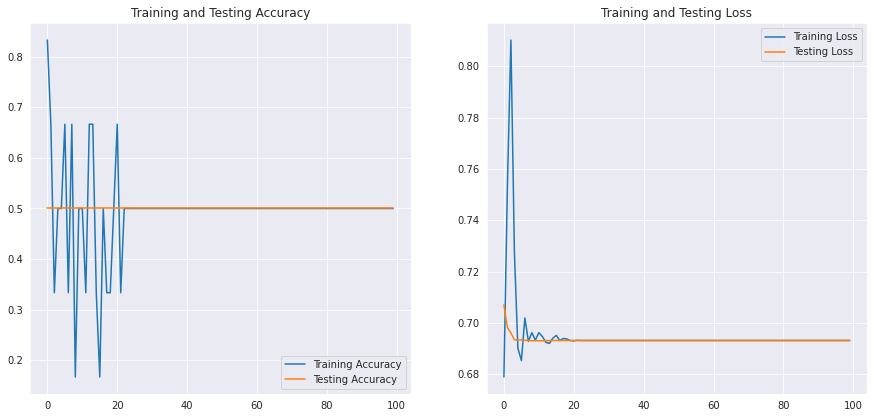

In [20]:
# Show the result of tranning and Testing set Result
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(100)

plt.figure(figsize=(15, 15))
plt.subplot(2, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Testing Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Testing Accuracy')

plt.subplot(2, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Testing Loss')
plt.legend(loc='upper right')
plt.title('Training and Testing Loss')
plt.show()

## Predicted Testing Dataset

In [21]:
def getClass(value):
    if(value[1] >= value[0]):
        return(1)
    else:
        return(0)
    
# predict test data
predictions = model.predict(x_test)

# Get class of prediction
prediction_class = []
for val in predictions[:,]:
    prediction_class.append(getClass(val))

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:22: RuntimeWarning: invalid value encountered in long_scalars


Evaluation Result
-----------------
Accuracy:     0.5
Sensitivity:  0.0
Specificity:  1.0
Precision:    nan
F1 Score:     0.0





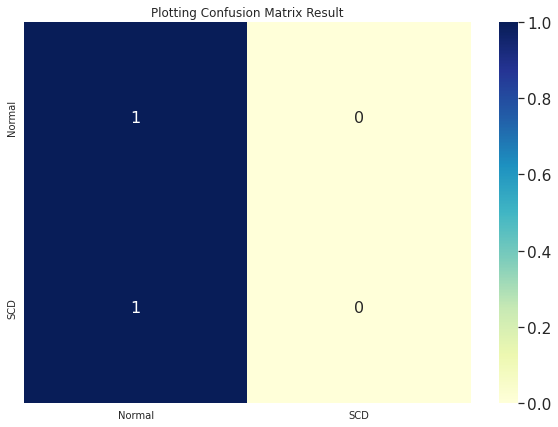

In [22]:
evalution(y_test, prediction_class)

In [23]:
# Save model 
model.save("Model/CNN_LSTM_model_v1")


# Save data Training and testing
np.save('Model/x_train.csv', x_train)
np.save('Model/x_test.csv', x_test)
np.save('Model/y_train.csv', y_train)
np.save('Model/y_test.csv', y_test)

INFO:tensorflow:Assets written to: Model/CNN_LSTM_model_v1/assets
